# Projeto de WebScraping do site AdoroCinema
## Membros do Grupo:
Bruno Milhomem Da Silveira e Luis Fernando Gracioli

# Coleta dos dados

In [ ]:
# Importa a biblioteca requests para fazer requisições HTTP
import requests

# Importa BeautifulSoup da biblioteca bs4 para fazer o parsing do HTML
from bs4 import BeautifulSoup

url = "https://www.adorocinema.com/filmes/criticas-filmes/"

# Faz uma requisição HTTP para obter o conteúdo da página
resposta = requests.get(url)

# Utiliza o BeautifulSoup para fazer o parsing do HTML da página
soup = BeautifulSoup(resposta.text, 'html.parser')

# 2. Busca todos os elementos <li> com a classe 'hred', que contêm os filmes listados
filmes = soup.find_all('li', class_='hred')

# 3. itera sobre cada filme encontrado na listagem
for filme in filmes:
    # Busca o elemento <h2> dentro do bloco do filme, que contém o título
    h2 = filme.find('h2')
    # Extrai o texto do título, ou usa um valor padrão se não encontrar
    nome_filme = h2.get_text(strip=True) if h2 else 'Título não encontrado'

    # Busca a tag <a> com atributo 'href', que contém o link para a página do filme
    a_tag = filme.find('a', href=True)
    if not a_tag:
        continue  # Se não encontrar o link, pula para o próximo filme
    # Concatena o link base com o link parcial da tag <a>
    link_filme = "https://www.adorocinema.com" + a_tag['href']

    # 4. Acessa a página individual do filme
    resposta_filme = requests.get(link_filme)
    # Faz o parsing do HTML da página do filme
    soup_filme = BeautifulSoup(resposta_filme.text, 'html.parser')

    # 5. Busca a seção de direção (classe 'meta-body-direction')
    direcao_tag = soup_filme.find('div', class_='meta-body-direction')
    # Extrai o texto, remove o prefixo "Direção:" e trata casos em que não encontra a informação
    direcao = direcao_tag.get_text(strip=True).replace('Direção:', '') if direcao_tag else 'Não encontrada'

    # 6. Busca a seção de elenco (classe 'meta-body-actor')
    elenco_tag = soup_filme.find('div', class_='meta-body-actor')
    # Extrai o texto e remove o prefixo "Elenco:"
    elenco = elenco_tag.get_text(strip=True).replace('Elenco:', '') if elenco_tag else 'Não encontrado'

    # 7. Busca a data de lançamento (tag <span> com classe 'date')
    data_tag = soup_filme.find('span', class_='date')
    # Extrai a data de lançamento, se disponível
    data = data_tag.get_text(strip=True) if data_tag else 'Não encontrada'

    # 8. Busca o meio de lançamento (cinema, streaming, etc)
    meio_tag = soup_filme.find('span', class_='meta-release-type')
    # Extrai o texto do meio de lançamento
    meio = meio_tag.get_text(strip=True) if meio_tag else 'nao encontrado'

    # 9. Busca a nota da crítica do AdoroCinema (span com classe 'stareval-note')
    nota_tag = soup_filme.find('span', class_='stareval-note')
    # Converte a string da nota para float, trocando vírgula por ponto
    nota_string = nota_tag.get_text(strip=True).replace(',', '.')
    nota = float(nota_string) if nota_tag else 'Nota da redação não encontrada'

    # 10. Exibe os dados extraídos do filme formatados
    print(f"   Título: {nome_filme}")
    print(f"   Direção: {direcao}")
    print(f"   Elenco: {elenco}")
    print(f"   Data: {data}")
    print(f'   Meio de lançamento: {meio}')
    print(f"   Nota AdoroCinema: {nota}")
    print("-" * 60)  # Separador visual entre os filmes


   Título: Bailarina - Do Universo de John Wick
   Direção: Len Wiseman
   Elenco: Ana de Armas,Ian McShane,Anjelica Huston
   Data: 5 de junho de 2025
   Meio de lançamento: No cinema
   Nota AdoroCinema: 4.1
------------------------------------------------------------
   Título: Lilo & Stitch
   Direção: Não encontrada
   Elenco: Não encontrado
   Data: Não encontrada
   Meio de lançamento: nao encontrado
   Nota AdoroCinema: 3.5
------------------------------------------------------------
   Título: Missão Impossível - O Acerto Final
   Direção: Christopher McQuarrie
   Elenco: Tom Cruise,Hayley Atwell,Simon Pegg
   Data: 22 de maio de 2025
   Meio de lançamento: No cinema
   Nota AdoroCinema: 4.3
------------------------------------------------------------
   Título: Premonição 6: Laços de Sangue
   Direção: Zach Lipovsky,Adam B. Stein
   Elenco: Brec Bassinger,Teo Briones,Kaitlyn Santa Juana
   Data: 15 de maio de 2025
   Meio de lançamento: No cinema
   Nota AdoroCinema: 4.0
----

# Coleta dos dados para uma lista modelo CSV

In [ ]:
# Cria uma lista vazia para armazenar os dados dos filmes extraídos
lista_filmes = []

# Itera sobre cada elemento de filme obtido previamente na listagem
for filme in filmes:
    # Busca o título do filme dentro da tag <h2>
    h2 = filme.find('h2')
    # Extrai o texto do título ou define como "Título não encontrado" se não existir
    nome_filme = h2.get_text(strip=True) if h2 else 'Título não encontrado'

    # Busca a tag <a> com link para a página individual do filme
    a_tag = filme.find('a', href=True)
    if not a_tag:
        continue  # Se não encontrar o link, pula para o próximo filme
    # Monta a URL completa da página do filme
    link_filme = "https://www.adorocinema.com" + a_tag['href']

    # Faz uma requisição para obter o conteúdo da página do filme
    resposta_filme = requests.get(link_filme)
    # Faz o parsing do HTML da página do filme
    soup_filme = BeautifulSoup(resposta_filme.text, 'html.parser')

    # Busca a informação da direção do filme (div com classe 'meta-body-direction')
    direcao_tag = soup_filme.find('div', class_='meta-body-direction')
    # Extrai e limpa o texto, removendo o prefixo "Direção:"
    direcao = direcao_tag.get_text(strip=True).replace('Direção:', '') if direcao_tag else 'Não encontrada'

    # Busca a informação do elenco (div com classe 'meta-body-actor')
    elenco_tag = soup_filme.find('div', class_='meta-body-actor')
    # Extrai e limpa o texto, removendo o prefixo "Elenco:"
    elenco = elenco_tag.get_text(strip=True).replace('Elenco:', '') if elenco_tag else 'Não encontrado'

    # Busca a data de lançamento do filme (span com classe 'date')
    data_tag = soup_filme.find('span', class_='date')
    # Extrai o texto da data
    data = data_tag.get_text(strip=True) if data_tag else 'Não encontrada'

    # Busca o meio de lançamento (cinema, streaming, etc.)
    meio_tag = soup_filme.find('span', class_='meta-release-type')
    # Extrai o texto do meio de lançamento
    meio = meio_tag.get_text(strip=True) if meio_tag else 'Não encontrado'

    # Busca a nota da crítica da redação (span com classe 'stareval-note')
    nota_tag = soup_filme.find('span', class_='stareval-note')
    # Extrai o texto da nota, substitui vírgula por ponto e converte para float
    nota_string = nota_tag.get_text(strip=True).replace(',', '.')
    nota = float(nota_string) if nota_tag else 'Nota da redação não encontrada'

    # Adiciona um dicionário com os dados do filme à lista de filmes
    lista_filmes.append({
        'nome do filme': nome_filme,
        'direcao': direcao,
        'elenco': elenco,
        'data': data,
        'meio de lançamento': meio,
        'nota': nota
    })

# Itera sobre a lista de filmes coletados e imprime os dados de cada um
for item in lista_filmes:
    print(item)


{'nome do filme': 'Bailarina - Do Universo de John Wick', 'direcao': 'Len Wiseman', 'elenco': 'Ana de Armas,Ian McShane,Anjelica Huston', 'data': '5 de junho de 2025', 'meio de lançamento': 'No cinema', 'nota': 4.1}
{'nome do filme': 'Lilo & Stitch', 'direcao': 'Não encontrada', 'elenco': 'Não encontrado', 'data': 'Não encontrada', 'meio de lançamento': 'Não encontrado', 'nota': 3.5}
{'nome do filme': 'Missão Impossível - O Acerto Final', 'direcao': 'Christopher McQuarrie', 'elenco': 'Tom Cruise,Hayley Atwell,Simon Pegg', 'data': '22 de maio de 2025', 'meio de lançamento': 'No cinema', 'nota': 4.3}
{'nome do filme': 'Premonição 6: Laços de Sangue', 'direcao': 'Zach Lipovsky,Adam B. Stein', 'elenco': 'Brec Bassinger,Teo Briones,Kaitlyn Santa Juana', 'data': '15 de maio de 2025', 'meio de lançamento': 'No cinema', 'nota': 4.0}
{'nome do filme': 'Homem com H', 'direcao': 'Esmir Filho', 'elenco': 'Jesuíta Barbosa,Bruno Montaleone,Jullio Reis', 'data': '1 de maio de 2025', 'meio de lançamen

# Criação do DataFrame

In [ ]:
import pandas as pd

df = pd.DataFrame(lista_filmes) # Cria o dataframe de lista_filmes
df

,nome do filme,direcao,elenco,data,meio de lançamento,nota
0,Bailarina - Do Universo de John Wick,Len Wiseman,"Ana de Armas,Ian McShane,Anjelica Huston",5 de junho de 2025,No cinema,4.1
1,Lilo & Stitch,Não encontrada,Não encontrado,Não encontrada,Não encontrado,3.5
2,Missão Impossível - O Acerto Final,Christopher McQuarrie,"Tom Cruise,Hayley Atwell,Simon Pegg",22 de maio de 2025,No cinema,4.3
3,Premonição 6: Laços de Sangue,"Zach Lipovsky,Adam B. Stein","Brec Bassinger,Teo Briones,Kaitlyn Santa Juana",15 de maio de 2025,No cinema,4.0
4,Homem com H,Esmir Filho,"Jesuíta Barbosa,Bruno Montaleone,Jullio Reis",1 de maio de 2025,No cinema,4.2
5,Thunderbolts*,Jake Schreier,"Florence Pugh,Sebastian Stan,David Harbour",1 de maio de 2025,No cinema,4.2
6,Pecadores,Ryan Coogler,"Michael B. Jordan,Hailee Steinfeld,Miles Caton",17 de abril de 2025,No cinema,4.2
7,Tempo de Guerra,"Ray Mendoza,Alex Garland","D'Pharaoh Woon-A-Tai,Charles Melton,Joseph Quinn",17 de abril de 2025,No cinema,3.3
8,Um Filme Minecraft,Jared Hess,"Jack Black,Jason Momoa,Danielle Brooks",3 de abril de 2025,No cinema,2.3
9,Branca de Neve,Marc Webb,"Rachel Zegler,Gal Gadot,Andrew Burnap",20 de março de 2025,No cinema,2.8


# Gráfico: Distribuição das notas dos filmes

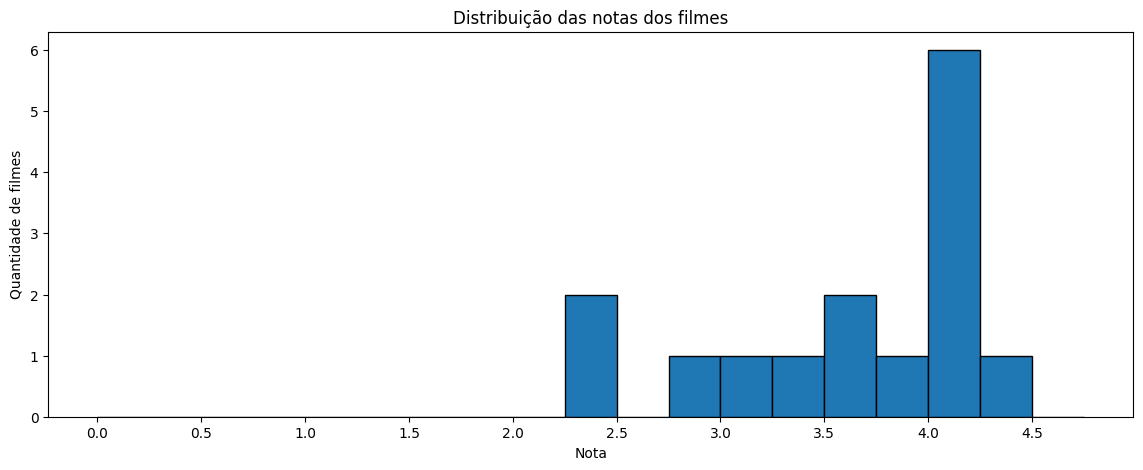

In [ ]:
import matplotlib.pyplot as plt

# Importa numpy para manipulação numérica, especialmente para criar os bins do histograma
import numpy as np

# Cria um array de intervalos para as barras do histograma, de 0 até 5, com passos de 0.25
bins = np.arange(0, 5, 0.25)

# Define o tamanho da figura do gráfico
plt.figure(figsize=(14, 5))

# Plota o histograma das notas dos filmes presentes no DataFrame 'df'
plt.hist(df['nota'], bins=bins, edgecolor='k')

# Define o título do gráfico
plt.title('Distribuição das notas dos filmes')

# Define o rótulo do eixo X como 'Nota'
plt.xlabel('Nota')

# Define o rótulo do eixo Y como 'Quantidade de filmes'
plt.ylabel('Quantidade de filmes')

# Define os valores do eixo X (notas) para aparecerem a cada 0.5 ponto
xticks = np.arange(0, 5, 0.5)
plt.xticks(xticks)

plt.show()

# Gráfico: Top 10 filmes com as piores notas

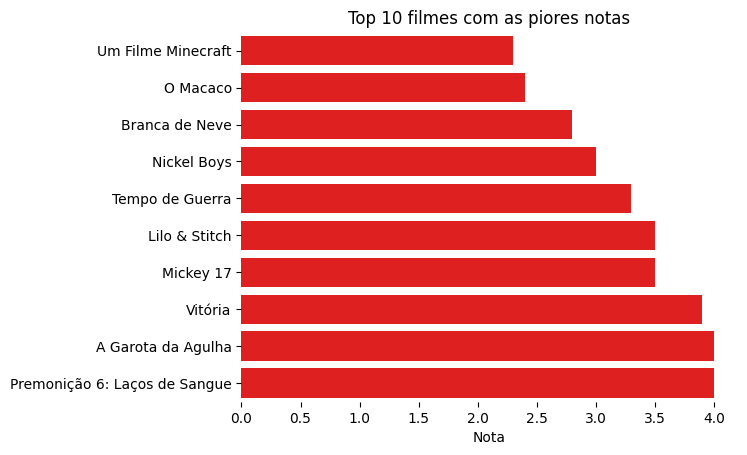

In [ ]:
import seaborn as sns

# Ordena o DataFrame 'df' pelas notas em ordem crescente e seleciona os 10 primeiros filmes,
# que correspondem aos filmes com as piores avaliações
piores_filmes = df.sort_values(by='nota', ascending=True).head(10)

# Cria um gráfico de barras horizontal mostrando as notas dos 10 piores filmes
# No eixo X temos as notas, no eixo Y os nomes dos filmes, e as barras são vermelhas para destacar
sns.barplot(x='nota', y='nome do filme', data=piores_filmes, color='red')

# Remove a borda da caixa ao redor do gráfico para melhorar a estética visual
plt.box(False)

plt.title('Top 10 filmes com as piores notas')
plt.xlabel('Nota')

# Mantém o rótulo do eixo Y vazio para evitar poluição visual no gráfico
plt.ylabel('')

plt.show()


# Gráfico: Top 10 filmes com as melhores notas

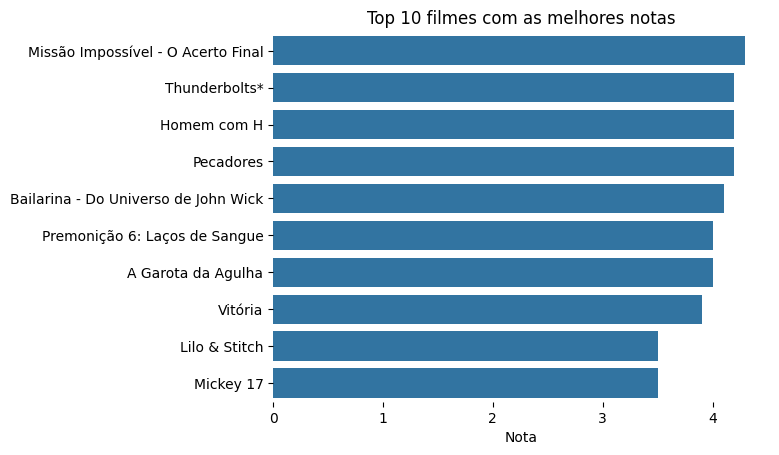

In [ ]:
import seaborn as sns

# Ordena o DataFrame 'df' pelas notas em ordem decrescente e seleciona os 10 primeiros filmes,
# que são os filmes com as melhores avaliações
top_filmes = df.sort_values(by='nota', ascending=False).head(10)

# Cria um gráfico de barras horizontal mostrando as notas dos 10 melhores filmes
# No eixo X temos as notas, no eixo Y os nomes dos filmes, com a cor padrão do seaborn
sns.barplot(x='nota', y='nome do filme', data=top_filmes)

# Remove a borda da caixa ao redor do gráfico para um visual mais limpo e profissional
plt.box(False)

plt.title('Top 10 filmes com as melhores notas')
plt.xlabel('Nota')

# Deixa o rótulo do eixo Y vazio para evitar excesso de informação visual
plt.ylabel('')

plt.show()
